# First doing the imports

In [9]:
from whoosh.index import create_in
from whoosh.index import open_dir
from whoosh.fields import *
import json
import os
from tqdm import tqdm
from whoosh.query import *
from whoosh.qparser import QueryParser, FuzzyTermPlugin, OrGroup
from whoosh.scoring import BM25F
import linecache
from google import genai
from pydantic import BaseModel
from typing import List
import pandas as pd
import numpy as np
import re
from matplotlib import pyplot as plt
import ast
import pickle as pkl
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

path_to_doc_chuncks = '/Users/tylergarfield/Desktop/school/CSC483/Rags_To_Searches/corpus/statpearls/chunk'
stop_words = stopwords.words('english')
lemmatizer = WordNetLemmatizer()

# Now we creat the index but we don't open it yet.

In [2]:
# First creating the schema, I really wanted to try to seperate out the distinct parts of each
# chunk into seperate fields that are independently searchable.
schema = Schema(doc_id = ID(stored=True), article_title = TEXT(stored=True), \
                section_title = TEXT(stored=True), content=TEXT(stored=True))

ix = create_in("woosh_index",schema)

# I want to look at the json chuncks first and perhaps do some prelinary cleanup getting the special sysmbols out of there.

In [3]:
# List out all the articles containing the chuncks to index.
docs_in_durr = os.listdir(path_to_doc_chuncks)

ind_writer = ix.writer()

try:

    for file in tqdm(docs_in_durr,total=len(docs_in_durr)):
    
        with open(f'{path_to_doc_chuncks}/{file}','r',encoding="utf-8") as f:
            
            for line in f:

                # Load next chunck in the current article.
                curr_art_chunk = json.loads(line)

                # extract the content of body of the chunck and the id.
                doc_id_curr = curr_art_chunk['id']
                cont_curr = curr_art_chunk['content']

                # Next excract the articles overall title and the section title.
                article_sec = curr_art_chunk['title'].split('--')
                main_title_curr = article_sec[0]
                sec_header_curr = article_sec[1]

                # Now write a new entry for the current chunck to the index.
                ind_writer.add_document(doc_id=doc_id_curr,article_title=main_title_curr,\
                                        section_title=sec_header_curr,content=cont_curr)

    ind_writer.commit()

    print("Woosh index was saved safely, let's look at this thing!")
        
except Exception as e:
    print("Owe no writing of index didn't complete successfully!❌")
    print(f"Error was: {e}")
    ind_writer.cancel()


ix.close()


100%|███████████████████████████████████████████████████████████████████████████████| 9632/9632 [01:17<00:00, 124.83it/s]


Woosh index was saved safely, let's look at this thing!


# Now that the index has been built I am going to test out querying it

In [10]:
ix = open_dir("woosh_index")


with ix.searcher() as searcher:
    print(searcher.doc_count())
    parser = QueryParser("content",ix.schema)
    parser.add_plugin(FuzzyTermPlugin())

    #query_curr = parser.parse('section_title:(history AND physical)^10 AND ((headache AND backache)^0.2 OR diarhea~2^3.5 AND vomiting^2)')
    #query_curr = parser.parse('section_title:(history AND physical)^2 AND content:"headache vomiting"~1')
    query_curr = parser.parse('section_title:(history AND physical)^2 AND (content:headache~2^2 vomiting~2^2)')
    print(query_curr)
    print('\n\n')
    
    test_res = searcher.search(query_curr,limit=20)

    # Print out the context of the best and worst results to see what they are talking about and the list
    # of ranked diseases based upon the article titles.
    print("-------------Top Res Content------------")
    print(f'{test_res[0]["doc_id"]}: {test_res[0]["content"]}\n\n')

    print("-------------Worst Res Content------------")
    print(f'{test_res[len(test_res.top_n)-1]["doc_id"]}: {test_res[len(test_res.top_n)-1]["content"]}\n\n')


    print("-------------Possible Diseases------------")
    for res in test_res:
        print(f'\t {res.rank}) {res["article_title"]} |{res.score:.4f}|')

ix.close()

361140
(section_title:history^2.0 AND section_title:physical^2.0 AND content:headache~2^4.000000 AND content:vomiting~2^4.000000)



-------------Top Res Content------------
article-27743_23: The location of the tumor, supratentorial or infratentorial, is important for the manifestation of symptoms. Those with an infratentorial location usually develop hydrocephalus with headache, vomiting, irritability, and lethargy. Ataxia or other cerebellar signs and cranial nerve palsies are common. They rarely have seizures. In supratentorial locations, vomiting, seizures, and headaches are common. Hemiparesis is present if the tumor affects the cortical motor areas or the descending tracts. The presentation is also affected by age. Younger patients present irritability, vomiting, and visual problems. Those older than three years usually show headaches, vomiting, and ataxia. [8]


-------------Worst Res Content------------
article-25161_14: Patients usually present within a month of treatment wit

# Next looking at the set of medical test questions that we found and trying to use that as a benchmark for how our system is performing.

In [4]:
med_qs_path = '/Users/tylergarfield/Desktop/school/CSC483/Rags_To_Searches/50k.csv'
mqs_df = pd.read_csv(med_qs_path)
# Do a preliminary reguralization of the question to increase the chances of it getting a result.
mqs_df['question'] = mqs_df['question'].apply(lambda x: re.sub(r'[^\w\s]','',x).lower())
mqs_df

,id,question,opa,opb,opc,opd,cop,choice_type,exp,subject_name,topic_name
0,7007efe5-88cb-4469-807b-74ff91928c59,most common site of mucosa associated lymphoid...,Stomach,Duodenum,Jejunum,Ileum,3,single,MALT is aggregation of lymphocytes present in ...,Anatomy,NaN
1,212e054f-acc4-49dd-84f7-af637d52a36e,action of adrenaline on which of the following...,α1,α2,β1,β2,1,single,Action of adrenaline is necessary on:\nα1 Rece...,Pharmacology,NaN
2,2266de82-0948-4742-8dc5-fe71613690fe,painful vaginal ulcer with inguinal lymphadeno...,Syphilis,LGV,Granuloma inguinale,Chancroid,3,single,"Ans. is. 'd' i. e., Chancroid",Microbiology,NaN
3,ea98544d-2b35-42ec-b86a-bf7b69733890,increased risk of endometrial and ovarian canc...,Hereditary nonpolyposis colorectal cancer,Peutz-jeghers syndrome,Cowden's syndrome,Ataxia telangiectasia,0,single,HNPCC or Lynch II syndrome is caused by an inh...,Gynaecology & Obstetrics,Gynaecological oncology
4,910ce5cc-3aed-43ae-ac07-f084f337737a,which of the following grains can be used safe...,Rice,Wheat,Rye,Barley,0,single,Answer is A (Rice) Gluten Containing Grains Wh...,Medicine,NaN
...,...,...,...,...,...,...,...,...,...,...,...
49995,bd045cd0-a964-482a-b31a-27b7a99bc699,a 60yearold man whose wife passed away 3 month...,Delusional disorder,Psychotic depression,Grief psychosis,Schizophrenia,1,single,(B) Psychotic depression > DSM-IV-TR Criteria ...,Psychiatry,Miscellaneous
49996,eef4bc79-54f8-44a9-97a5-47bdc62e9822,cognitive model of depression is given by,Ellis,Beck,Godfrey,Meicheinbanon,1,single,Beck Cognitive therapy is a psychotherapy deve...,Psychiatry,NaN
49997,74880b14-3214-4b79-b7c8-4959fd96be5b,which of the milestone develops first,Mirror play,Crawling,Creeping,Pincer grasp,0,single,"Ans. is 'a' i.e., Mirror play o A child enjoys...",Pediatrics,NaN
49998,66ef0278-34fb-4c53-900b-4e089e4b08dd,a patient with cancer received extreme degree ...,Vincristine,Dactinomycin,Cyclophosphamide,6-Mercaptopurine,1,single,"Ans. is 'b' i.e., Dactinomycin o The patient w...",Pharmacology,NaN


# Now to performe hyperparamater tuning on k and b to make our system performe as optimally as possible. Combination of Gemini which I prompted with what is below and trial and error, I came up with a subset of about 320 questions of the original 50k that I could use as a baseline to tune the hyperparamaters.




"Can you tell me which questions are the simplest and most likely to come up in my db so that I can use them to tune my hyperparamates via the MRR aproximate measure. My partner made a good point that since we are gonna use rag I shouldn't be as conserned abouot tyring to optimize my quieries and that not all of them are gonna have the direct answer in the text, given that I would prefer a relatively chuncky set of queries that would serve this purpose" 

### You don't need to run this.

In [45]:
good_querie_inds = list(good_querie_inds)

with open('/Users/tylergarfield/Desktop/school/CSC483/Rags_To_Searches/good_tuning.pkl','wb') as pkfl:
    pkl.dump(good_queries_inds,pkfl)

### Run the cells bellow.

In [6]:
good_querie_inds = []
with open('/Users/tylergarfield/Desktop/school/CSC483/Rags_To_Searches/good_tuning.pkl','rb') as pkfl:
    good_querie_inds = pkl.load(pkfl)

## Perform a grid search of reasonable k and b values to see which combo yeilds the best results. I know doing "in" to see if a reliventy query is retrieved is slightly flawed, it was just a good fast way to aproximate the health of the current paramaters.

Testing k1 = 1.20 b 0.65, 61 failed queries, zero div 0: 100%|██████████████████████████| 341/341 [00:49<00:00,  6.93it/s]
Testing k1 = 1.25 b 0.65, 61 failed queries, zero div 0: 100%|██████████████████████████| 341/341 [00:49<00:00,  6.90it/s]
Testing k1 = 1.30 b 0.65, 61 failed queries, zero div 0: 100%|██████████████████████████| 341/341 [00:49<00:00,  6.87it/s]
Testing k1 = 1.35 b 0.65, 61 failed queries, zero div 0: 100%|██████████████████████████| 341/341 [00:49<00:00,  6.84it/s]
Testing k1 = 1.40 b 0.65, 61 failed queries, zero div 0: 100%|██████████████████████████| 341/341 [00:49<00:00,  6.93it/s]
Testing k1 = 1.45 b 0.65, 61 failed queries, zero div 0: 100%|██████████████████████████| 341/341 [00:48<00:00,  6.96it/s]
Testing k1 = 1.50 b 0.65, 61 failed queries, zero div 0: 100%|██████████████████████████| 341/341 [00:49<00:00,  6.95it/s]
Testing k1 = 1.55 b 0.65, 61 failed queries, zero div 0: 100%|██████████████████████████| 341/341 [00:49<00:00,  6.91it/s]
Testing k1 = 1.6

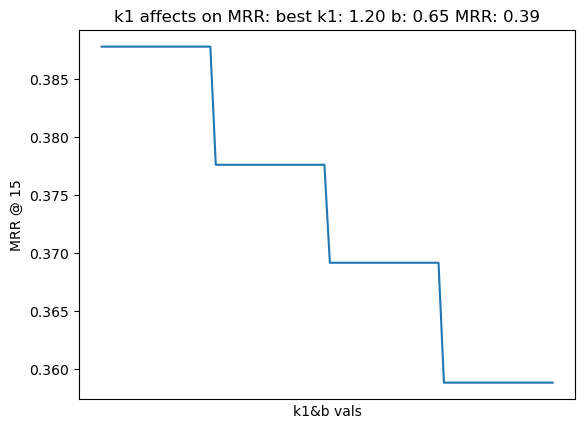

In [12]:
# First we'll start by defining the range of k that will be tested.
ix = open_dir("woosh_index")
k1_search = np.arange(1.2,2.2,0.05)
b_search = np.arange(0.65,0.8,0.05)
kb_pairs = np.array(np.meshgrid(k1_search,b_search,indexing='ij')).T.reshape(-1,2)


opc_cols = ['opa','opb','opc','opd']

# This is the list of indexes for queries that Gemini said would have the best chance of passing the in test.
# Since we are going to use a RAG system for my hyperparamater tuning I want to just use a set of questions
# that are most likely to retieve the needed context to purley tune the hyperparamaters. I figuered using Gemini
# would be a good quick way to look up good highly relivent questions from the original set.

#good_tuning_inds = []
#with open('/Users/tylergarfield/Desktop/school/CSC483/Rags_To_Searches/tuning_indices.txt','r') as f:
    #inds_list = f.read()
    #good_tuning_inds = ast.literal_eval(inds_list)

# Load the questions.
benchmark_qs = mqs_df.to_dict('records')


# Initialize all the tracking paramaters.
mrr_vals = []
failed_qs_all = set()
best_kb = None
best_mrr = 0

for kb_pair in kb_pairs:

    # Get the next pair of k and b values to try out.
    k1_val = kb_pair[0]
    b_val = kb_pair[1]
    
    with ix.searcher(weighting=BM25F(B=b_val,k1=k1_val)) as searcher:
        # Set the summation value to zero initially.
        tot_mr = 0

        # Create progress bar and initial description that denotes the current k and b testing values.
        pbar = tqdm(good_querie_inds,total=len(good_querie_inds))
        pbar.set_description(f'Testing k1 = {k1_val:.2f} b = {b_val:.2f}, 0 failed queries')

        # Track failed queries.
        failed_qs = 0
        zero_div = 0
        
        for ind in pbar:

            # Get the correct answer for this question.
            record = benchmark_qs[ind]
            correct_ans_colind = record['cop']
            correct_ans = record[opc_cols[correct_ans_colind]].lower().strip()
    
            try:
        
                # Try to normalize the question terms as much as possible.
                normed_terms = [Term("content",tok.lower().strip('!?$%#*&|)([]{}')) for tok in record['question'].split()]
                q_or = Or(normed_terms) # Join together with a or.

                # Now search the formulated query
                test_res = searcher.search(q_or,limit=15)

                # Normalize the answer before doing this in test.
                ans_tokens = [lemmatizer.lemmatize(tok.lower().strip('!?$%#*&|)([]{}')) for tok in correct_ans.split()]
                # Now we are going to do a set operation to remove all the stop words.
                ans_tokens = list(set(ans_tokens)-set(stop_words))

                # Initially the rank is zero so that if it stays there we know there were no results.
                rank = 0
                for res in test_res:
                    rank_j = res.pos+1

                    # Now get the current context tokens
                    cont_tokens = [lemmatizer.lemmatize(tok.lower().strip('!?$%#*&|)([]{}')) for tok in res['content'].split()]
                    all_in = True

                    # Now check if all the answer tokens are in the content tokens.
                    for ans_tok in ans_tokens:
                        if ans_tok not in cont_tokens:
                            all_in = False
                            
                    if all_in:
                        rank = rank_j
                        break

                # Calc adition to MRR for the current query.
                if rank != 0:
                    tot_mr += 1/rank
                else: # Handle error.
                    failed_qs += 1
                    pbar.set_description(f'Testing k1 = {k1_val:.2f} b {b_val:.2f}, {failed_qs} failed queries, zero div {zero_div}')
                    failed_qs_all.add(correct_ans)
                    
            except ZeroDivisionError: # Handle errors.
                failed_qs += 1
                zero_div += 1
                pbar.set_description(f'Testing k1 = {k1_val:.2f} b {b_val:.2f}, {failed_qs} failed queries, zero div {zero_div}')
                failed_qs_all.add(correct_ans)

        # Calc final MRR
        
        mrr = tot_mr/len(good_querie_inds)
        mrr_vals.append(mrr)

        # See if these hyperparamaters were best.
        if mrr > best_mrr:
            best_mrr = mrr
            best_kb = kb_pair
        


ix.close()

x_marks = np.arange(0,kb_pairs.shape[0])
plt.plot(x_marks,mrr_vals)
plt.xticks(ticks=[])
plt.xlabel('k1&b vals')
plt.ylabel('MRR @ 15')
plt.title(f'k1 affects on MRR: best k1: {best_kb[0]:.2f} b: {best_kb[1]:.2f} MRR: {best_mrr:.2f}')
plt.show()

In [15]:
ix = open_dir("woosh_index")

opc_cols = ['opa','opb','opc','opd']
failed_queries = []
zero_div_qs = []



mrr = 0
with ix.searcher(weighting=BM25F(B=0.3,k1=1.2)) as searcher:

    parser = QueryParser("content",ix.schema,group=OrGroup.factory())
    
    benchmark_qs = mqs_df.to_dict('records')
    tot_mr = 0
    pbar = tqdm(benchmark_qs,total=len(benchmark_qs))
    pbar.set_description('Zero failed questions')
    for record in pbar:

        try:
            correct_ans_colind = record['cop']
            correct_ans = record[opc_cols[correct_ans_colind]].lower().strip()
    
            # Try to normalize the question terms as much as possible.
            normed_terms = [Term("content",tok.lower().strip('!?$%#*&|)([]{}')) for tok in record['question'].split()]
            q_or = Or(normed_terms) # Join together with a or.

            # Now search the formulated query
            test_res = searcher.search(q_or,limit=15)

            # Normalize the answer before doing this in test.
            ans_tokens = [lemmatizer.lemmatize(tok.lower().strip('!?$%#*&|)([]{}')) for tok in correct_ans.split()]
            # Now we are going to do a set operation to remove all the stop words.
            ans_tokens = list(set(ans_tokens)-set(stop_words))

            # Initially the rank is zero so that if it stays there we know there were no results.
            rank = 0
            for res in test_res:
                rank_j = res.pos+1

                # Now get the current context tokens
                cont_tokens = [lemmatizer.lemmatize(tok.lower().strip('!?$%#*&|)([]{}')) for tok in res['content'].split()]
                all_in = True

                # Now check if all the answer tokens are in the content tokens.
                for ans_tok in ans_tokens:
                    if ans_tok not in cont_tokens:
                        all_in = False
                            
                if all_in:
                    rank = rank_j
                    break
    
            if rank != 0:
                tot_mr += 1/rank
            else:
                failed_queries.append(record['question'])
                pbar.set_description(f'Failed zero res queries at {len(failed_queries)} Zero div {len(zero_div_qs)}')
                
        except ZeroDivisionError:
            zero_div_qs.append(record['question'])
            pbar.set_description(f'Failed zero res queries at {len(failed_queries)} Zero div {len(zero_div_qs)}')

    mrr = tot_mr/len(benchmark_qs)
            
ix.close()

print(f'MRR at 15 is: {mrr}') 

Failed zero res queries at 36227 Zero div 0: 100%|████████████████████████████████| 50000/50000 [3:29:43<00:00,  3.97it/s]

MRR at 15 is: 0.13146002813852412


# Takeaway of trying to get Whoosh to work:

### The takeaway of this notebook is this. First, with respect to the k1 and b parameters, k1 was best when it was a little bit smaller than the default, and b was best when it was significantly smaller than the default. So we know that a low k1 corresponds to no term frequency and a low b corresponds to no length normalization. My hypothesis for diminished term frequency being better is that most of the relevant medical terms only appear once or twice in any given document. Thus the document fequency for a given term carried much more meaningful information that needed more attention then the term frequency. For the low b, since this corpus was created with the specific design of fixed-length chunks for RAG, most chunks were roughly the same size, and size carried very little meaningful information. But some length normalization was still needed, as not all documents were the exact same length.

### However, the final conclusion with an MRR at 15 of just about 0.131 is that Whoosh is not best aligned with the use and goal of our RAG project. The lexical nature of the queries significantly hampers our ability to pull meaningful context. For our pruposes we need our context to be as similar as possible to the given question, but this search needs to be in a semantic space and not a lexical based space. The next thing we will do is devote all our attention to tuning FAISS to give our RAG pipeline the most relevant and precise context, given our query.

